In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from scipy import linalg
from scipy.special import gamma

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 16.8 #15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [20]:
bins = np.logspace(9, M_max, 79)

In [21]:
M_min_array_old = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [22]:
fduty_old = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_23422/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_23422/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


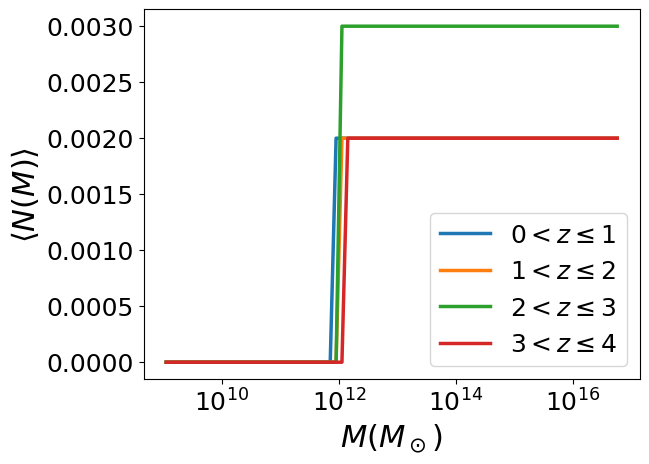

In [23]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [24]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [25]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [26]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

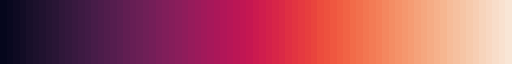

In [27]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [28]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [29]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [30]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

0.6894778799187598
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              224099 vs 324336
0.6998052038245415
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464321 vs 648196
0.7010382664423291
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6: 0.22              28576 vs 36458


In [31]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [32]:
LMC_radius = 9*u.deg

In [33]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [34]:
SMC_radius = 5*u.deg

In [35]:
NPIX = hp.nside2npix(NSIDE)

In [36]:
theta, phi = hp.pix2ang(NSIDE, range(NPIX), lonlat=True)
c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
MC_idx = np.append(LMC_idx,SMC_idx)
MC_mask = np.full_like(range(NPIX), True, dtype = bool)
MC_mask[MC_idx] = False

In [37]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
        N = len(tab_datahi_mask_zbins[j])
        cp = np.percentile(selfunc_hi_bins[j][MC_mask], mask*100)
        selfunc_mask = selfunc_hi_bins[j]>=cp
        f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
        print(f_sky)
        V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
        N_q.append(N)
        n_q.append(N/V.value)
        n_q_err.append(np.sqrt(N)/V.value) # Poisson error
        V_eff.append(V)

n_q, n_q_err

0.3815553400077859
0.3990266387789277
0.42567567827451197
0.43715916212910605


([1.1562053955390066e-05,
  8.122737301033735e-06,
  3.0936220453800634e-06,
  2.72364137384074e-07],
 [2.442390108471359e-08,
  1.1920466314375162e-08,
  6.679103548998666e-09,
  1.6111990760486273e-09])

In [38]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [39]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [46]:
# Create the bins array
rmin = 30.0 #-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 180.0 #80 #+delta_max*offset # 200
nbins = 30 #10 #int((rmax-rmin)/offset) #20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([ 30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,
         85.,  90.,  95., 100., 105., 110., 115., 120., 125., 130., 135.,
        140., 145., 150., 155., 160., 165., 170., 175., 180.]),
 array([ 32.5,  37.5,  42.5,  47.5,  52.5,  57.5,  62.5,  67.5,  72.5,
         77.5,  82.5,  87.5,  92.5,  97.5, 102.5, 107.5, 112.5, 117.5,
        122.5, 127.5, 132.5, 137.5, 142.5, 147.5, 152.5, 157.5, 162.5,
        167.5, 172.5, 177.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [47]:
pimax = 80 # 40 # 5000.0 # 40.0\

In [48]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [49]:
mask_max = 80

### Pick cosmology

In [50]:
cosmo = 'Planck'

In [60]:
float(a)

0.5808398371301335

In [114]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = [], [], []
b_wp_chi2 = []
a_zbin, b_wp_q = [], []
rpmask = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    # tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
    #                                                                                  bins = [z_bins], tab_gcat_type = 'data',
    #                                                                                  method = ['minmax'], fac_rand = 25,
    #                                                                                  n_bins = [None], mask = mask*100, percentile = True)

    # try:

    wp_zbin_i = np.load('../results/wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax-20.0_{}_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], cosmo, mask))
    rpavg_zbin_i = np.load('../results/rpavg_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_Lmax-20.0_{}_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], cosmo, mask))
    a = float(np.load('../results/a_G{}_zmin{}zmax{}_Lmax-20.0_{}_MC_mask{}.npy'.format(G_hi, z_bins[j], z_bins[j+1], cosmo, mask)))

    # except:
        
    #     # quasar correlation function
    #     wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
    #                                                                   rbins = rbins, nbins = nbins, pimax = pimax, Om0 = Planck18.Om0, h = Planck18.h)

    #     np.save('../results/wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_N{}_{}_MC_mask{}'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, mask), wp_zbin_i)
    #     np.save('../results/rpavg_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{}zmax{}_N{}_{}_MC_mask{}'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, mask), rpavg_zbin_i)
            
    wp_chi2.append(wp_zbin_i)
    rpavg_chi2.append(rpavg_zbin_i)

    # scale factor
    # a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function   
    s = np.sqrt(np.sum(np.meshgrid(np.array(rpavg_zbin_i)**2, quaia.recenter(pibins)**2), axis = 0))
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
        
    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a)
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
    wp_matter_chi2.append(wp_matter_zbin_i)        

    # effective bias 
    b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
    b_wp_chi2.append(b)

    # qso bias
    b_wp_q.append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo_planck18, a)))
    
    rpmask.append((np.array(rpavg_zbin_i) >= 30) & (np.array(rpavg_zbin_i) <= mask_max))

/tmp/ipykernel_23422/1345243712.py:45: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_23422/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Compute the maximum number of jackknife regions

In [115]:
N_j = 50

In [116]:
fudge = 2.8
for j in z_array:

    r_LOS = Planck18.comoving_distance(1/a_zbin[j]-1)*Planck18.h/u.h
    theta_min = 2*np.arcsin(fudge*rmax*r_LOS.unit/2/r_LOS)
    N_jk_max = np.floor(2*np.pi*theta_min.unit/theta_min)
    
    print('N_j_max:', N_jk_max)
    print('N_q:', int(N_q[j]/N_j))
    print('theta_min:', theta_min)
    print()
    
print('hartlap:', (N_j-nbins-2)/(N_j-1))
print('dodelson:', 1+nbins/N_j)

N_j_max: 22.0
N_q: 4481
theta_min: 0.2826929330284417 rad

N_j_max: 37.0
N_q: 9286
theta_min: 0.16807716581243928 rad

N_j_max: 48.0
N_q: 4290
theta_min: 0.128564488773322 rad

N_j_max: 56.0
N_q: 571
theta_min: 0.11075550576978664 rad

hartlap: 0.3673469387755102
dodelson: 1.6


# Perform nested sampling with dynesty

In [117]:
# Define the dimensionality of our problem.
ndim = 1

In [118]:
N=50 #40 #20 #65 #50 #30 #15 #60

In [119]:
def wp_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, rpbins, pibins, recenter = True, rpmask = True):

    if not isinstance(wp_matter_zbin_i, np.ndarray):
        
        print('computing wp_matter')
        
        # matter correlation function    
        if isinstance(rpmask, bool):
            rpmask = [rpmask]*len(quaia.recenter(rpbins))
            
        s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)[rpmask]**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))

        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [120]:
# Define our 3-D correlated multivariate normal log-likelihood.
C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_Planck_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, mask)) 
ix_grid = np.ix_(rpmask[j], rpmask[j])
hartlap = (N-nbins-2)/(N-1)
print(hartlap)

# check if cov is hermitian and positive definite
if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
    C_factor = linalg.cho_factor(C[ix_grid])
    log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
    solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
else:
    print('using LU decomposition')
    C_factor = linalg.lu_factor(C[ix_grid])
    log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
    solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
    
def loglike(x, a, wp_matter, rpbins, pibins, log_det_C, wp, n_q, nbins, cosmo = cosmo_planck18, error = 0.05, hartlap = hartlap, solve = solve, N = N, M_max = M_max, f_duty = 0):
    
    M_min = x[0]
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**f_duty
    
    wp_2h_zbin, _ = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins, pibins, recenter = False)
    delta = wp-wp_2h_zbin
    
    c_p = gamma(N/2)/((np.pi*(N-1))**(nbins/2)*gamma((N-nbins)/2))
    lnorm = np.log(c_p)-0.5*log_det_C
    
    return -N*0.5 * np.log(1+(delta.T @ solve(delta))/(N-1)) + lnorm #- penalty

0.3673469387755102


In [121]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 
    
    # Uniform from 9 to 15
    x[0] = 6 * u[0] + 9  # scale and shift to [9., 15.)

    return x

In [122]:
nlive = 3000
dlogz = 0.01 #01

In [123]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], wp_matter_chi2[j][rpmask[j]], rbins, pibins, log_det_C, wp_chi2[j][rpmask[j]], n_q[j], nbins], logl_kwargs = {'error':0.05}, nlive = nlive)

In [124]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = dlogz)
results = sampler.results

15986it [00:33, 484.04it/s, +3000 | bound: 3 | nc: 1 | ncall: 117303 | eff(%): 16.610 | loglstar:   -inf < -54.064 <    inf | logz: -54.781 +/-  0.011 | dlogz:  0.000 >  0.010]


In [125]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 3000
niter: 15986
ncall: 114303
eff(%): 16.610
logz: -54.781 +/-  0.013


<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/2088523137.py:3: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)


Text(0.5, 0.9, '$3.0<z \\leq4.6$')

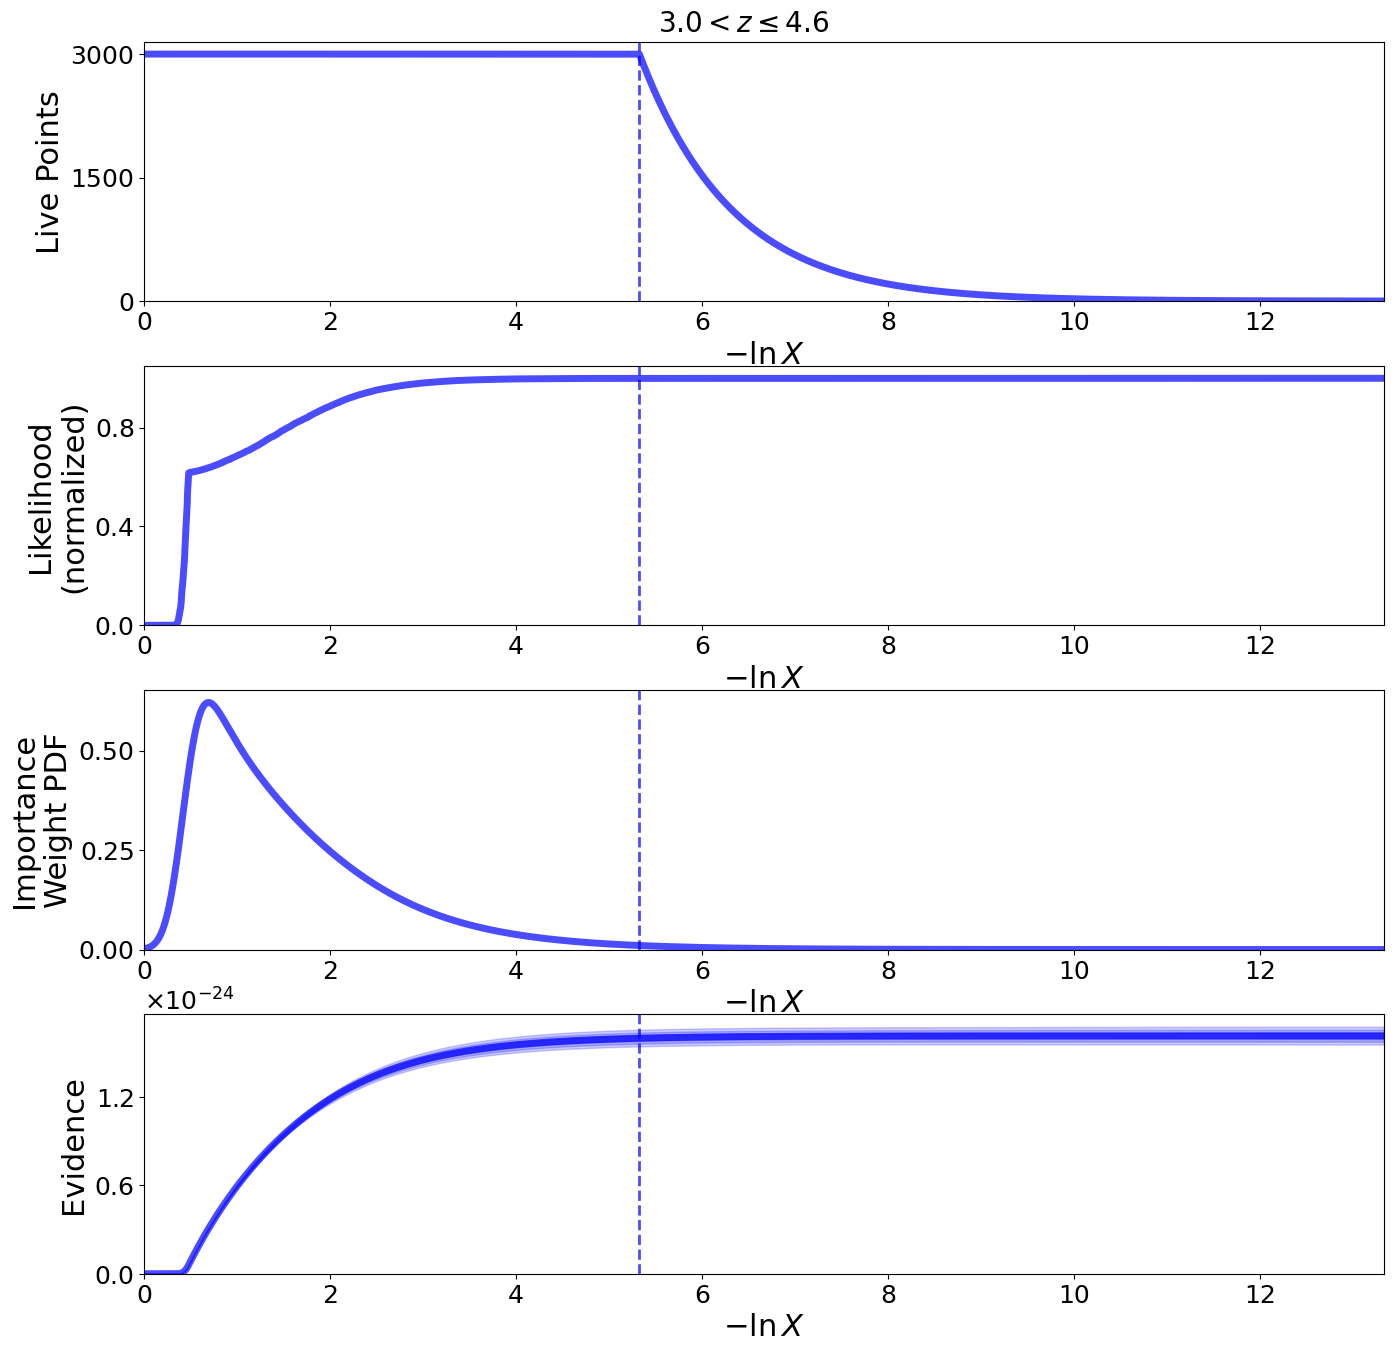

In [126]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/3321637555.py:6: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)


Text(0.5, 1, '$3.0<z \\leq4.6$')

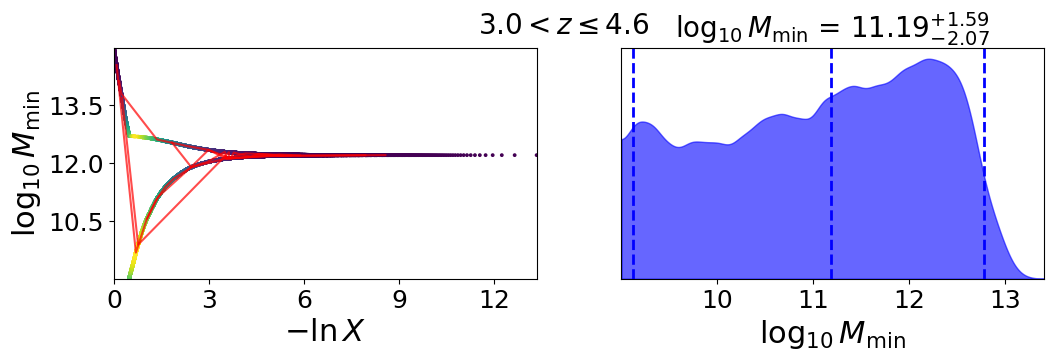

In [127]:
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/2603487664.py:8: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)


Text(0.375, 1, '$3.0<z \\leq4.6$')

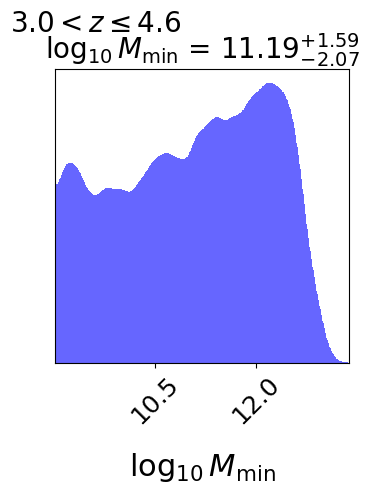

In [128]:
# # initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)

In [129]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[11.07658895] [[1.21546416]]


In [130]:
# Compute weighted quantiles
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(M_min): 11.19 + 1.59/-2.07


In [131]:
equal_weight_samples = dyfunc.resample_equal(samples, weights)

## Try fitting $f_{duty}$

In [132]:
bins_m = np.logspace(equal_weight_samples, M_max, 79)
n_m=np.ones(len(bins_m))

n_dm = []
for k in range(len(equal_weight_samples)):
    n_dm.append(M(bins_m[:,k][:,0], n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
equal_weight_samples_fduty = np.log10(n_q[j]/n_dm)

In [133]:
labels_fduty = [r'$\log_{10} f_\mathrm{duty}$']

In [134]:
# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, [0.16, 0.5, 0.84]) 

# for i, (lo, mid, hi) in enumerate(quantiles):
print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

$\log_{10} f_\mathrm{duty}$: -4.81 + 1.76/-1.69


## Across all $z$

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/1205711932.py:35: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)
/tmp/ipykernel_23422/1205711932.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
/tmp/ipykernel_23422/1205711932.py:51: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)
21585it [00:41, 514.51it/s, +3000 | bound: 6 | nc: 1 | ncall: 126451 | eff(%): 19.915 | loglstar:   -inf < -29.758 <    inf | logz: -32.342 +/-  0.026 | 

Summary
nlive: 3000
niter: 21585
ncall: 123451
eff(%): 19.915
logz: -32.342 +/-  0.027
0<z<=1
log10(M_min): 12.33 + 0.16/-0.22

$\log_{10} f_\mathrm{duty}$: -2.44 + 0.17/-0.23



22383it [00:42, 528.13it/s, +3000 | bound: 6 | nc: 1 | ncall: 127093 | eff(%): 20.455 | loglstar:   -inf < -25.158 <    inf | logz: -28.007 +/-  0.027 | dlogz:  0.000 >  0.010]


Summary
nlive: 3000
niter: 22383
ncall: 124093
eff(%): 20.455
logz: -28.007 +/-  0.029
1<z<=2
log10(M_min): 12.00 + 0.13/-0.16

$\log_{10} f_\mathrm{duty}$: -2.81 + 0.16/-0.18



21779it [00:41, 522.16it/s, +3000 | bound: 6 | nc: 1 | ncall: 124813 | eff(%): 20.342 | loglstar:   -inf < -35.123 <    inf | logz: -37.771 +/-  0.026 | dlogz:  0.000 >  0.010]


Summary
nlive: 3000
niter: 21779
ncall: 121813
eff(%): 20.342
logz: -37.771 +/-  0.027
2<z<=3
log10(M_min): 12.19 + 0.14/-0.20

$\log_{10} f_\mathrm{duty}$: -2.68 + 0.22/-0.28



15951it [00:32, 485.74it/s, +3000 | bound: 3 | nc: 1 | ncall: 116314 | eff(%): 16.724 | loglstar:   -inf < -54.064 <    inf | logz: -54.769 +/-  0.011 | dlogz:  0.000 >  0.010]


Summary
nlive: 3000
niter: 15951
ncall: 113314
eff(%): 16.724
logz: -54.769 +/-  0.012
3<z<=4
log10(M_min): 11.20 + 1.08/-1.47

$\log_{10} f_\mathrm{duty}$: -4.80 + 1.70/-1.70



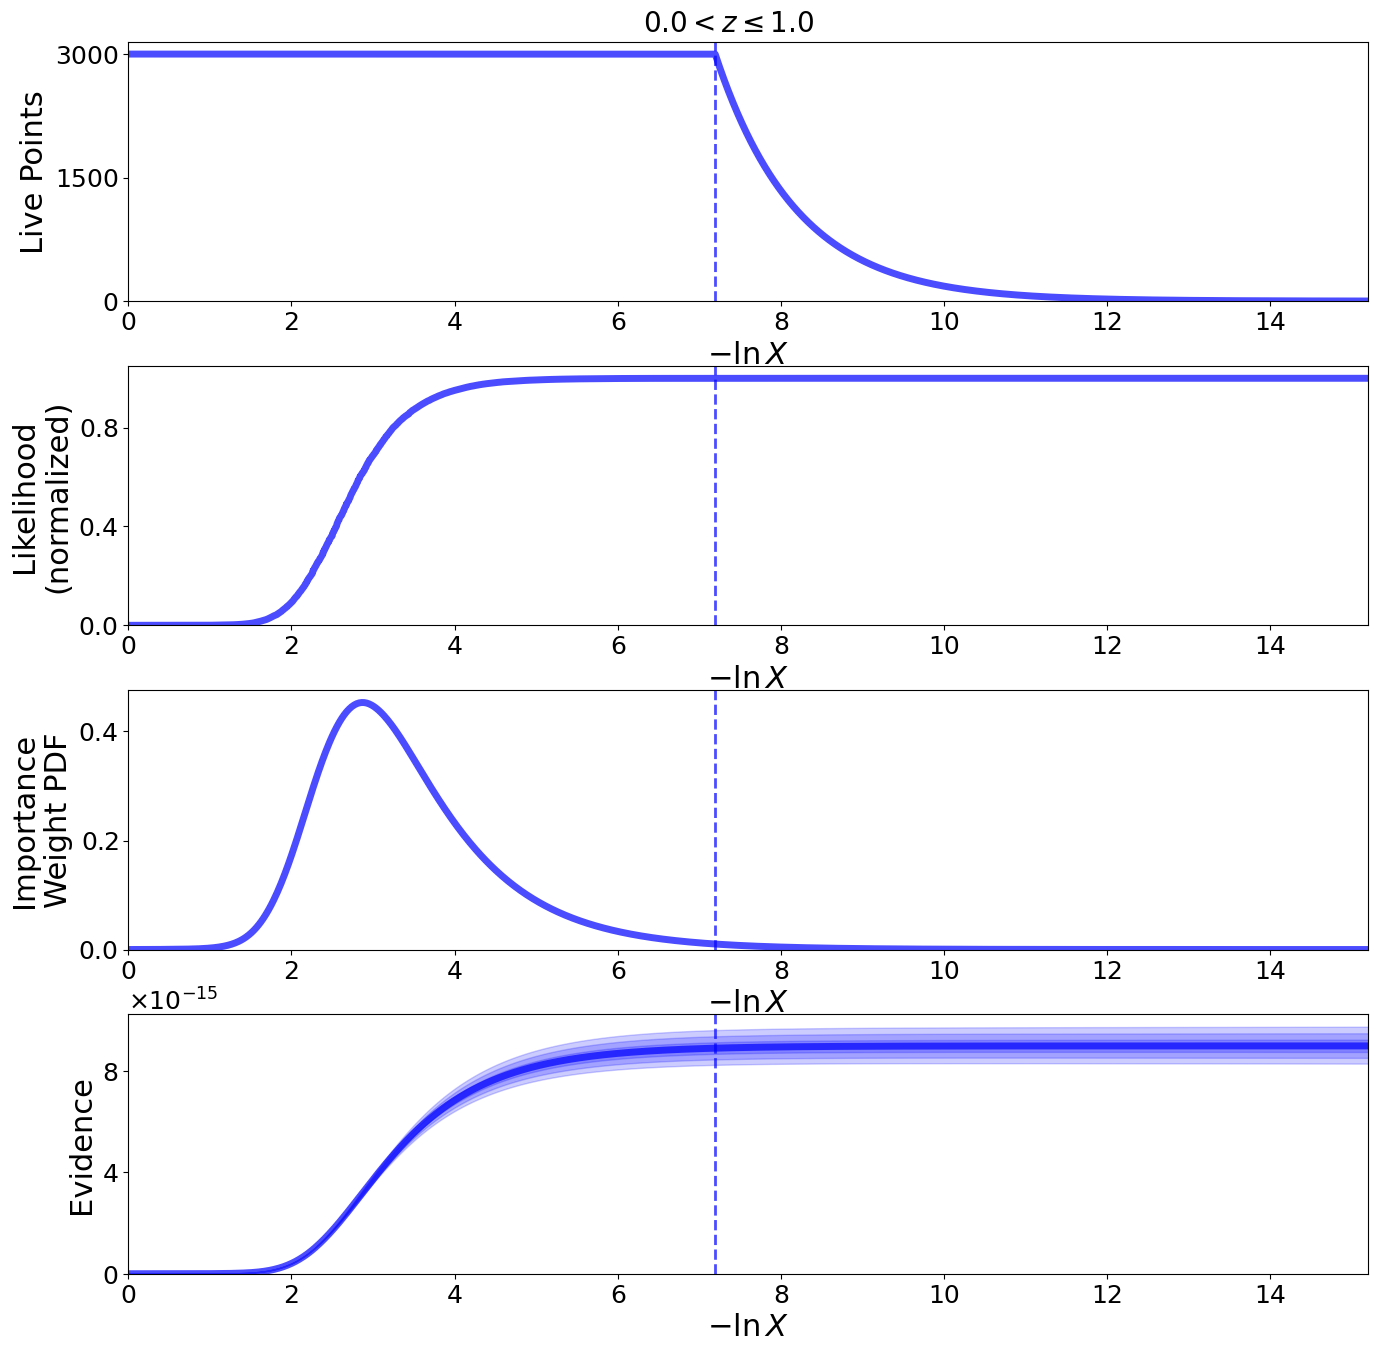

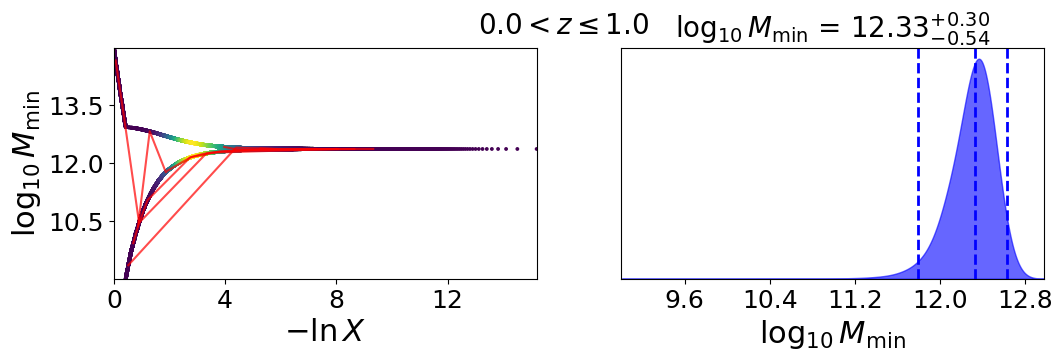

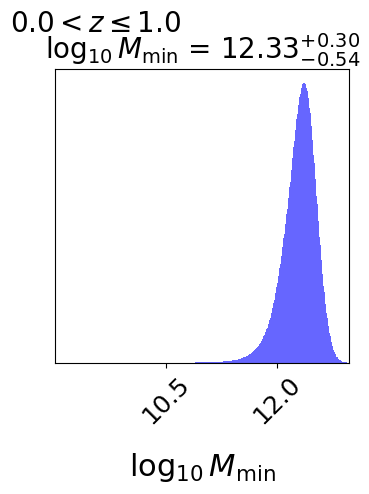

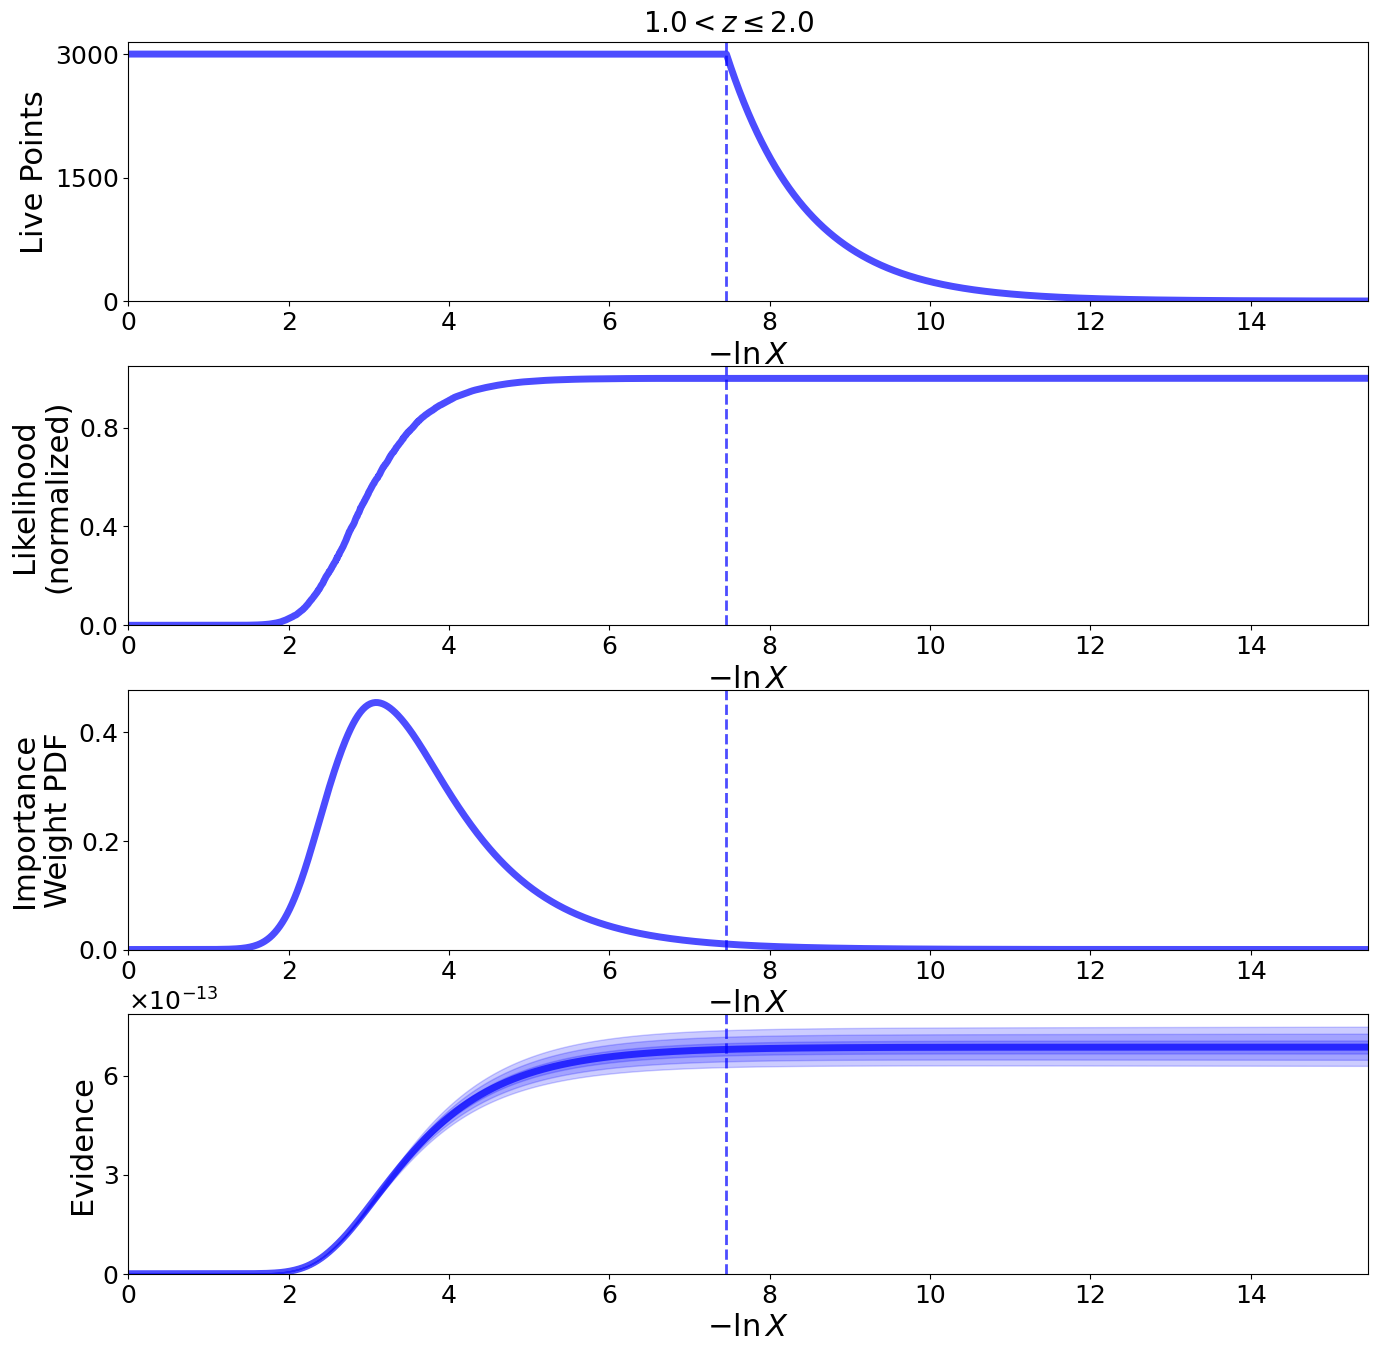

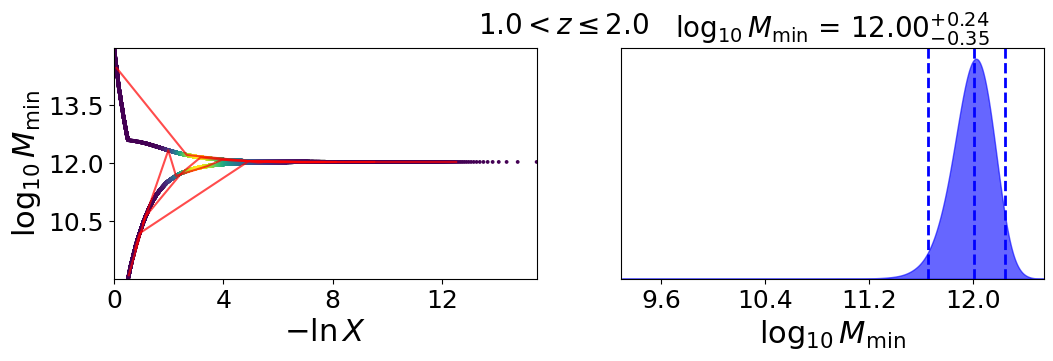

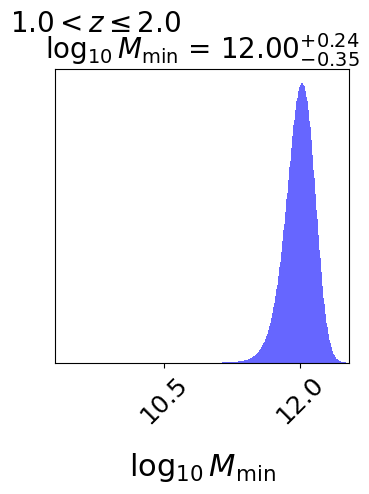

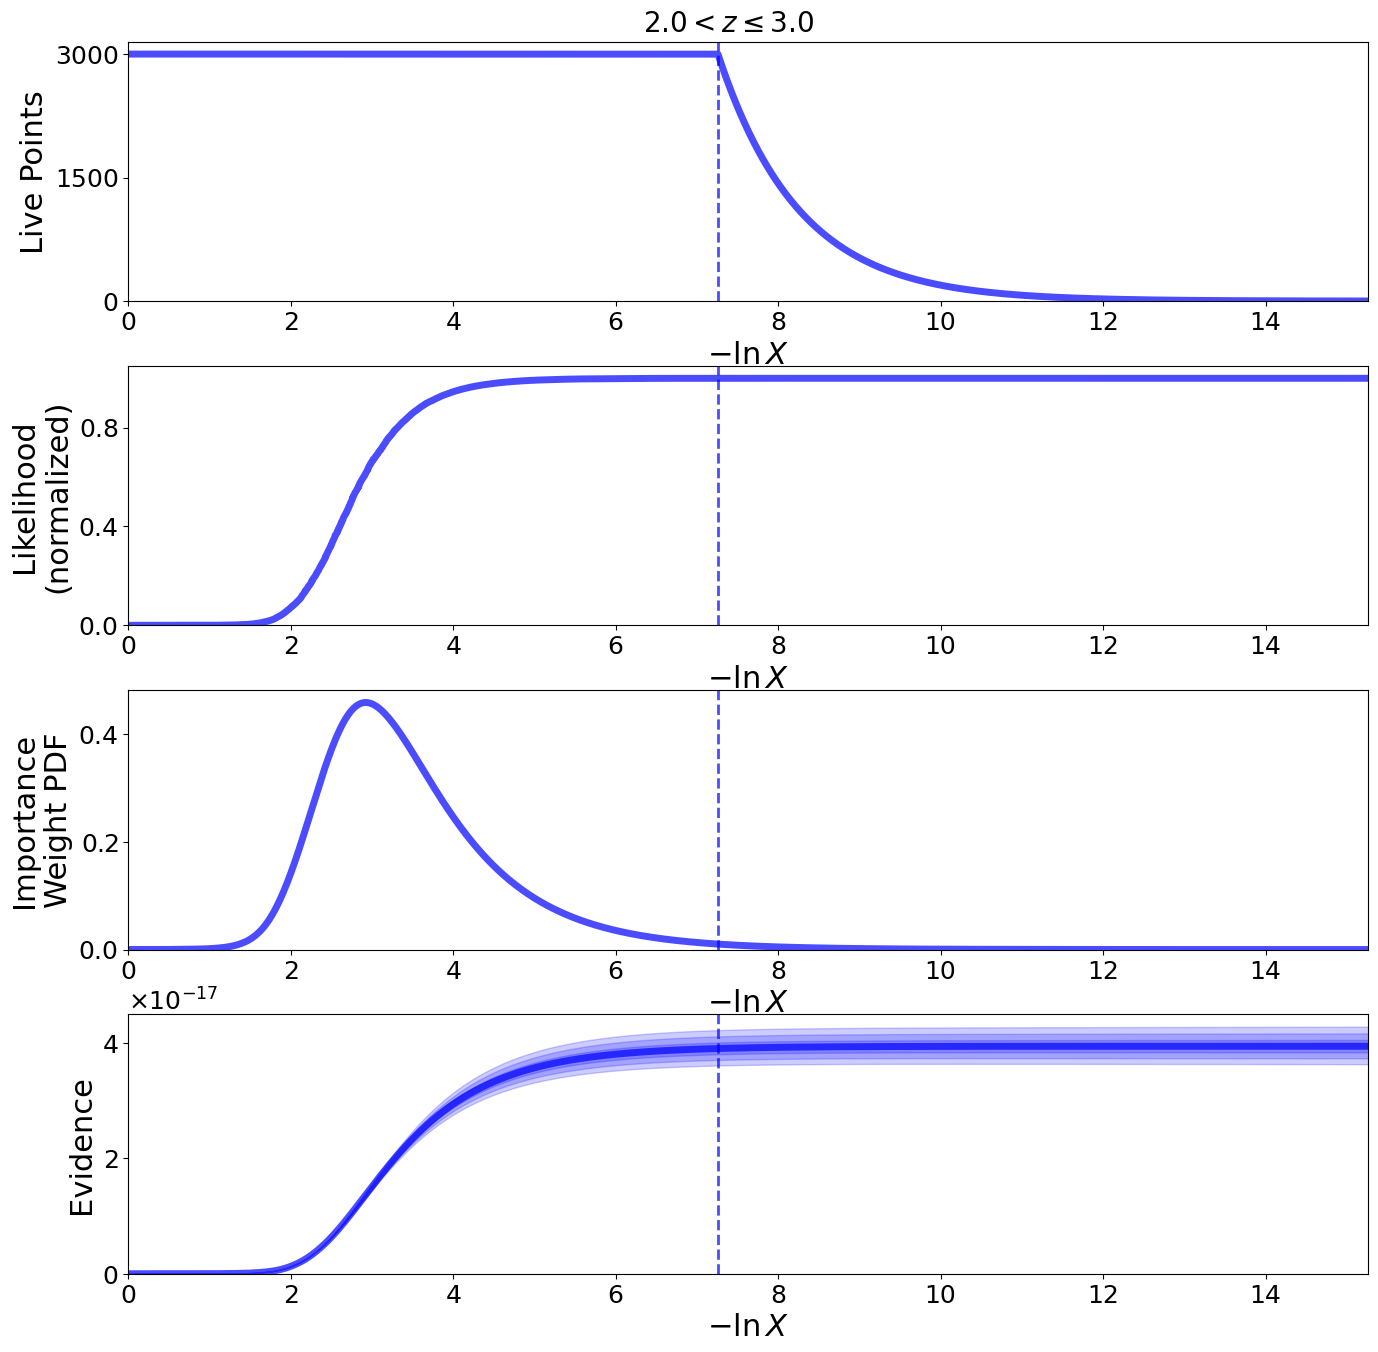

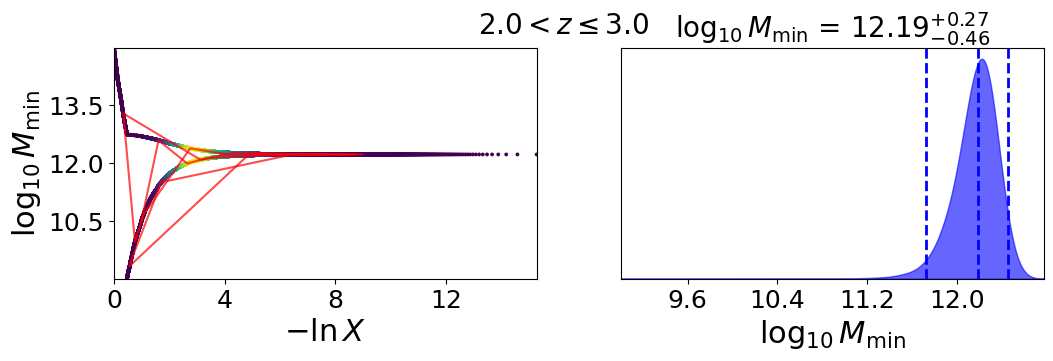

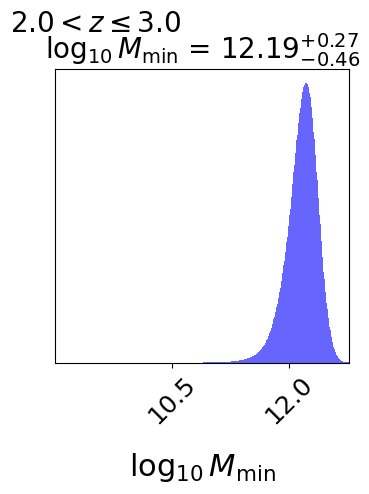

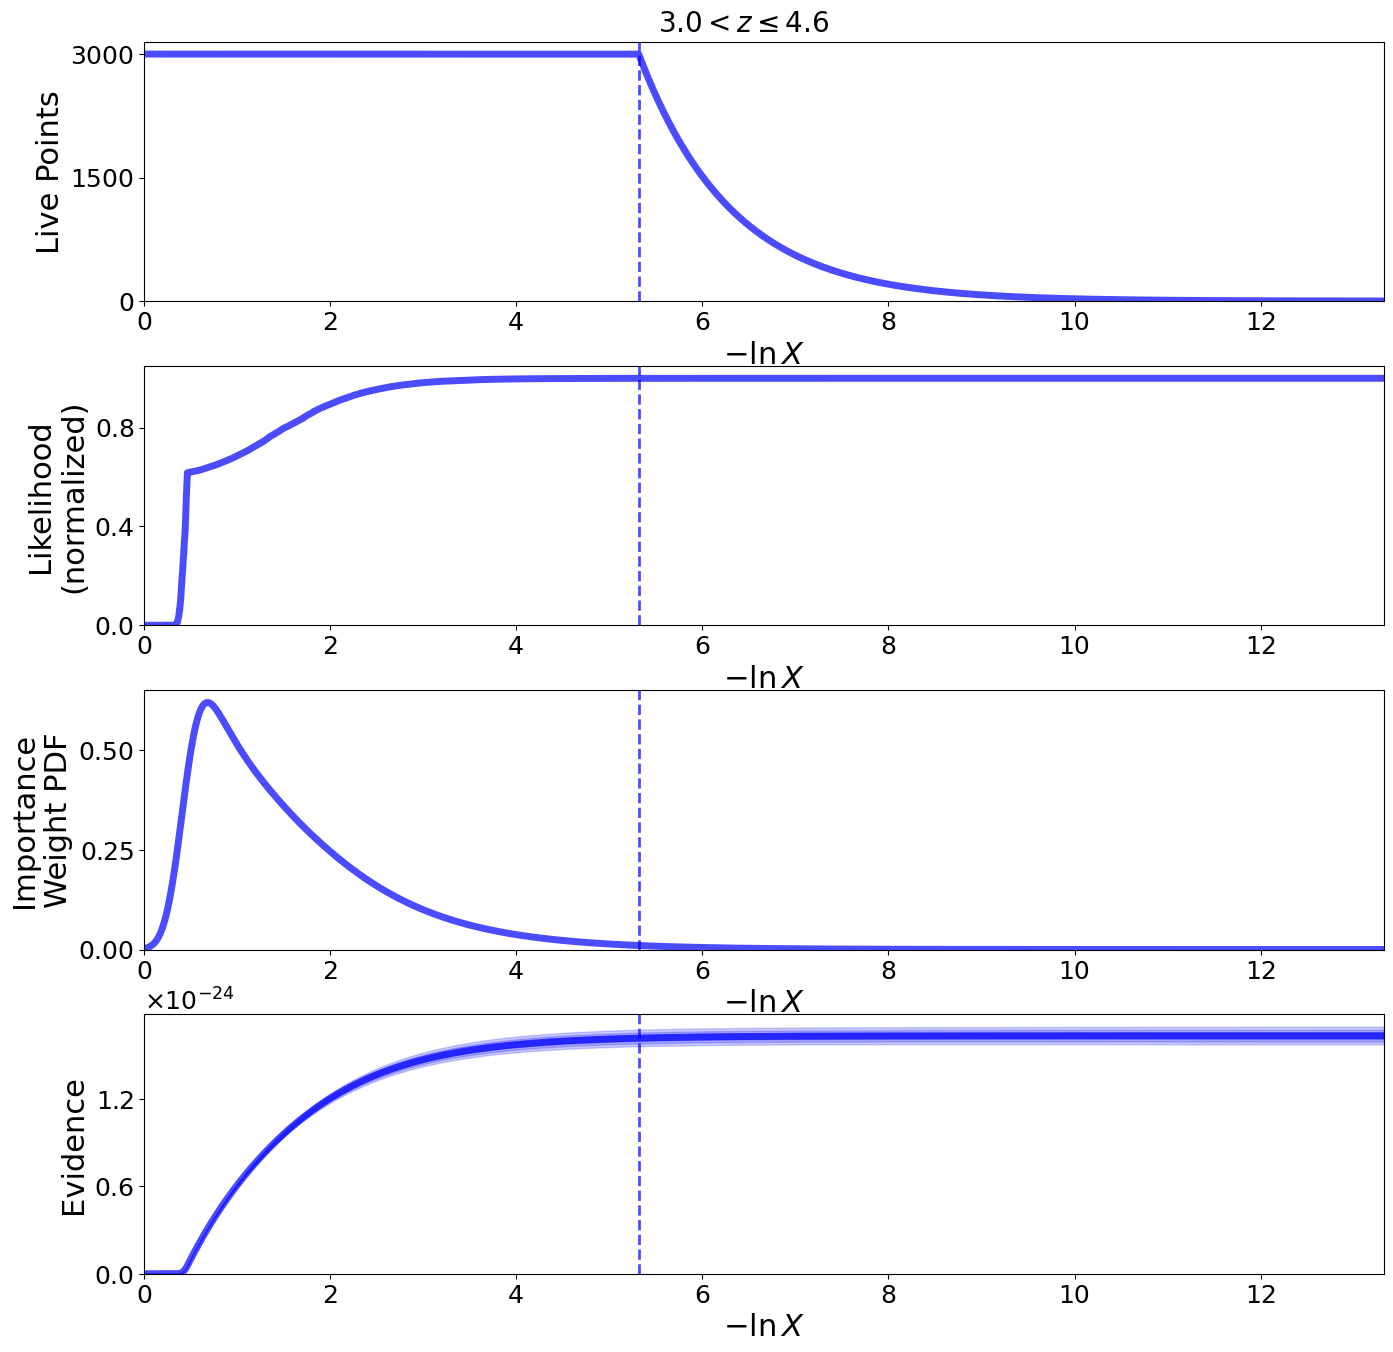

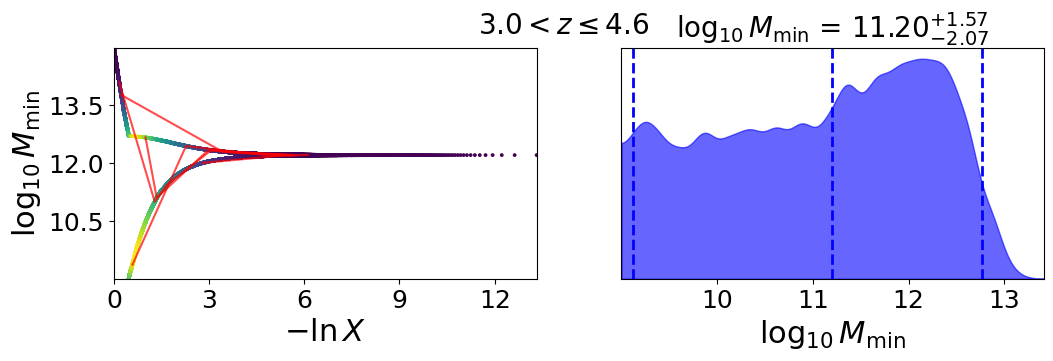

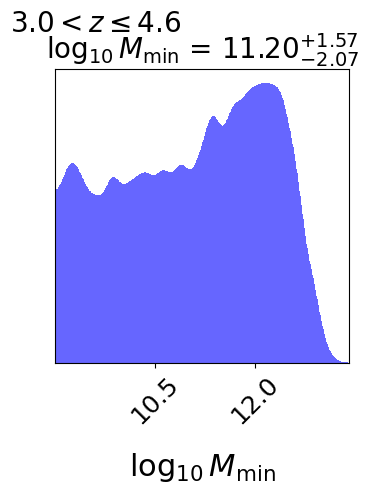

In [135]:
f_duty, M_min = [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
best_fit_params = []
logz = []
for j in z_array:
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_Planck_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, mask)) 
    ix_grid = np.ix_(rpmask[j], rpmask[j])

    # check if cov is hermitian and positive definite
    if linalg.ishermitian(C) and np.all(np.linalg.eigvals(C) > 0):
        C_factor = linalg.cho_factor(C[ix_grid])
        log_det_C = 2 * np.sum(np.log(np.diag(C_factor[0])))
        solve = lambda rhs: linalg.cho_solve(C_factor, rhs)
    else:
        print('using LU decomposition')
        C_factor = linalg.lu_factor(C[ix_grid])
        log_det_C = np.sum(np.log(np.abs(np.diag(C_factor[0])))) # does abs value make sense
        solve = lambda rhs: linalg.lu_solve(C_factor, rhs)
        
    # initialize our nested sampler
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], wp_matter_chi2[j][rpmask[j]], rbins, pibins, log_det_C, wp_chi2[j][rpmask[j]], n_q[j], nbins], logl_kwargs = {'error':0.05}, nlive = nlive)    
    
    # run the sampler with checkpointing
    sampler.run_nested(dlogz = dlogz)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 0.9)    
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    fig.suptitle('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), fontsize = 20, y = 1, x = 0.375)
    
    samples, weights = results.samples, results.importance_weights()

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for k, (lo, mid, hi) in enumerate(quantiles):
        k = -1
        print(f"{labels[k]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[k]].append((lo, hi))
    print()
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    M_min_samples.append(equal_weight_samples[ind][:,0])
    
    M_min.append(quantiles[0][1]) 

    # Get the maximum likelihood sample from dynesty results
    idx_max = np.argmax(results.logl)
    logz.append(results.logz[-1])

    # solve for fduty
    bins_m = np.logspace(equal_weight_samples[:,0], M_max, 79) #M_min_samples
    n_m=np.ones(len(bins_m))
    
    n_dm = [M(bins_m[:,k], n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for k in range(len(equal_weight_samples))]
    equal_weight_samples_fduty = np.log10(n_q[j]/n_dm)

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    lo, mid, hi = dyfunc.quantile(equal_weight_samples_fduty, [0.16, 0.5, 0.84]) 
    
    print(f"{labels_fduty[0]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}\n")
    err[labels[0]].append((lo, hi))

    f_duty.append(mid)

    ind = np.random.choice(range(len(equal_weight_samples_fduty)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples_fduty[ind])

    # # Get the maximum likelihood sample from dynesty results
    bins_m = np.logspace(samples[idx_max][0], M_max, 79)
    n_dm = M(bins_m, n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1]
        
    # Get the maximum likelihood sample from dynesty results
    idx_max = np.argmax(results.logl)
    best_fit_params.append((np.log10(n_q[j]/n_dm), samples[idx_max][0]))

In [136]:
np.save('../results/logz_wp_rmin{}_rmax{}_nbins{}_pimax{}_hard_Mmax{}_ndim{}_selfunc'.format(rmin, rmax, nbins, pimax, M_max, ndim), logz)

### Solve for $\chi_c^2=\Delta^T x$ where $Cx=\Delta$

In [137]:
def f0_GLS_solve(x, a, wp_matter, C, wp, rpbins, pibins, cosmo = cosmo_planck18, rpmask = True, hartlap = hartlap, M_max = M_max):  #quaia):
    
    f_duty, M_min = x
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**f_duty
        
    wp_2h_zbin, b_q = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins, pibins, recenter = False)
    
    if isinstance(rpmask, bool):
        rpmask = [rpmask]*len(quaia.recenter(rpbins))
    delta = (wp-wp_2h_zbin)[rpmask]
        
    return delta.T @ (hartlap*np.linalg.solve(C, delta))

### Add a number density constraint

In [138]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05, M_max = M_max):
    
    f_duty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**f_duty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [139]:
for j in z_array:
    
    print('{:.1f}<z<={:.1f}'.format(z_bins[j], z_bins[j+1]))
    x = f_duty[j], M_min[j]
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_Planck_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, mask)) 
    chi2 = f0_GLS_solve(best_fit_params[j], a_zbin[j], wp_matter_chi2[j], C, wp_chi2[j], rbins, pibins)
    df = nbins-len(x)

    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

0.0<z<=1.0
           chi^2: 27.49
   reduced chi^2: 0.98
         delta n: 4.94e-02
condition number: 173.68
             PTE: 0.49

1.0<z<=2.0
           chi^2: 29.09
   reduced chi^2: 1.04
         delta n: 4.98e-02
condition number: 60.93
             PTE: 0.41

2.0<z<=3.0
           chi^2: 33.62
   reduced chi^2: 1.20
         delta n: 4.90e-02
condition number: 111.29
             PTE: 0.21

3.0<z<=4.6
           chi^2: 127.42
   reduced chi^2: 4.55
         delta n: 4.72e-02
condition number: 322.17
             PTE: 0.00



## Plot results

In [140]:
zbin = 1/np.array(a_zbin)-1

In [141]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [142]:
M_min_err_hi = [0.04, 0.02, 0.03, 0.1]
M_min_err_lo = [0.05, 0.02, 0.03, 0.12]

In [143]:
cmap_purple = sns.color_palette("Purples", n_colors = len(zbin))

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/1924093483.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


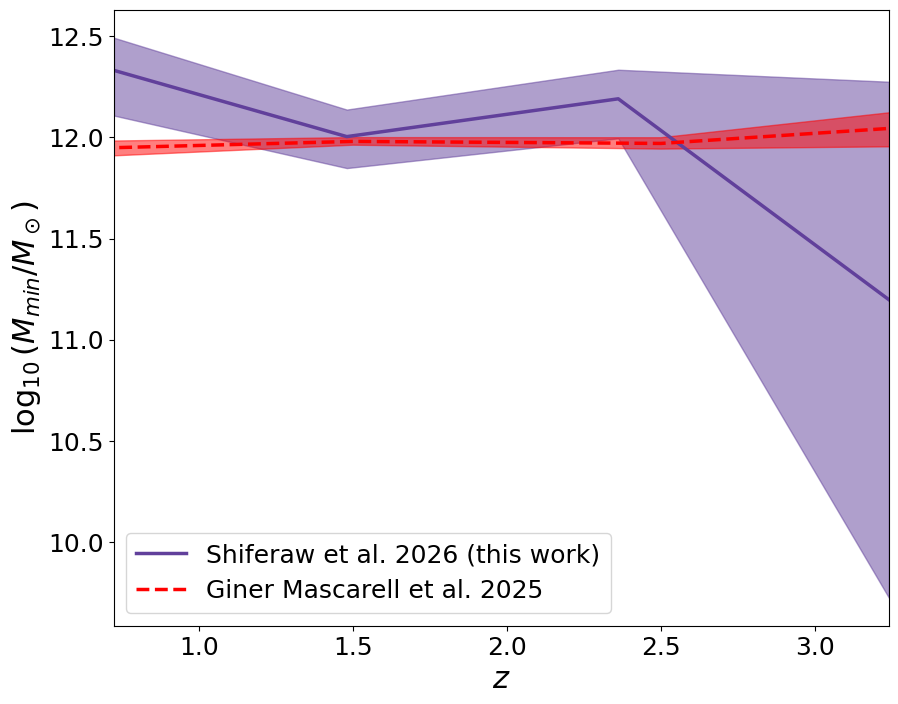

In [144]:
fig = plt.figure(figsize = (10, 8))
M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = cmap_purple[-1], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color =  cmap_purple[-1])
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'red', linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, M_min_array+np.array(M_min_array)/M_min_array_old*M_min_err_hi, M_min_array-np.array(M_min_array)/M_min_array_old*M_min_err_lo, alpha = 0.5, color = 'red')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(loc = 'lower left')
plt.xlim(zbin[0], zbin[-1])
plt.show()

In [145]:
np.save('../results/M_min_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard_Mmax{}_ndim{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz, M_max, ndim), M_min)

In [146]:
np.save('../results/log10(M_min)_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard_Mmax{}_ndim{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz, M_max, ndim), np.array(err['log10(M_min)']))

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/2154268093.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


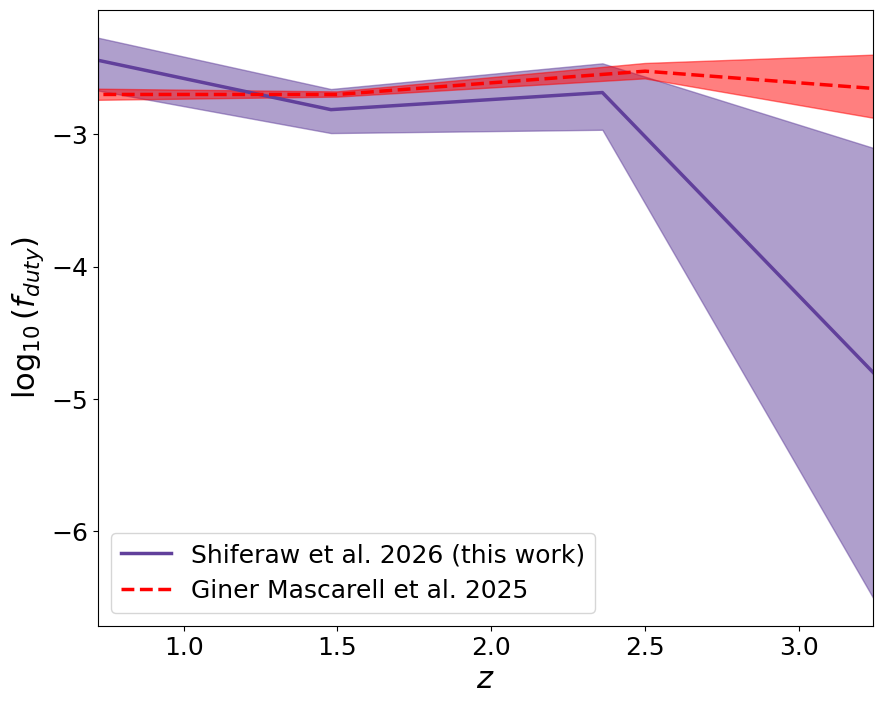

In [147]:
fig = plt.figure(figsize = (10, 8))
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = cmap_purple[-1], linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = cmap_purple[-1])
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'red', linewidth = 2.5, linestyle = '--')
plt.fill_between(z_eff, np.log10(np.array(fduty)+np.array(fduty)/fduty_old*fduty_err_hi), np.log10(np.array(fduty)-np.array(fduty)/fduty_old*fduty_err_lo), alpha = 0.5, color = 'red')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend()
plt.xlim(zbin[0], zbin[-1])
plt.show()

In [148]:
np.save('../results/f_duty_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard_Mmax{}_ndim{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz, M_max, ndim), f_duty)

In [149]:
np.save('../results/log10(f_duty)_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_{}_MC_mask_sellentin_nlive{}_dlogz{}_hard_Mmax{}_ndim{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, cosmo, nlive, dlogz, M_max, ndim), np.array(err['log10(f_duty)']))

In [150]:
b_eff_wp20 = np.load('../results/b_eff_wp20_planck18.npy')

<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/240366870.py:58: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))


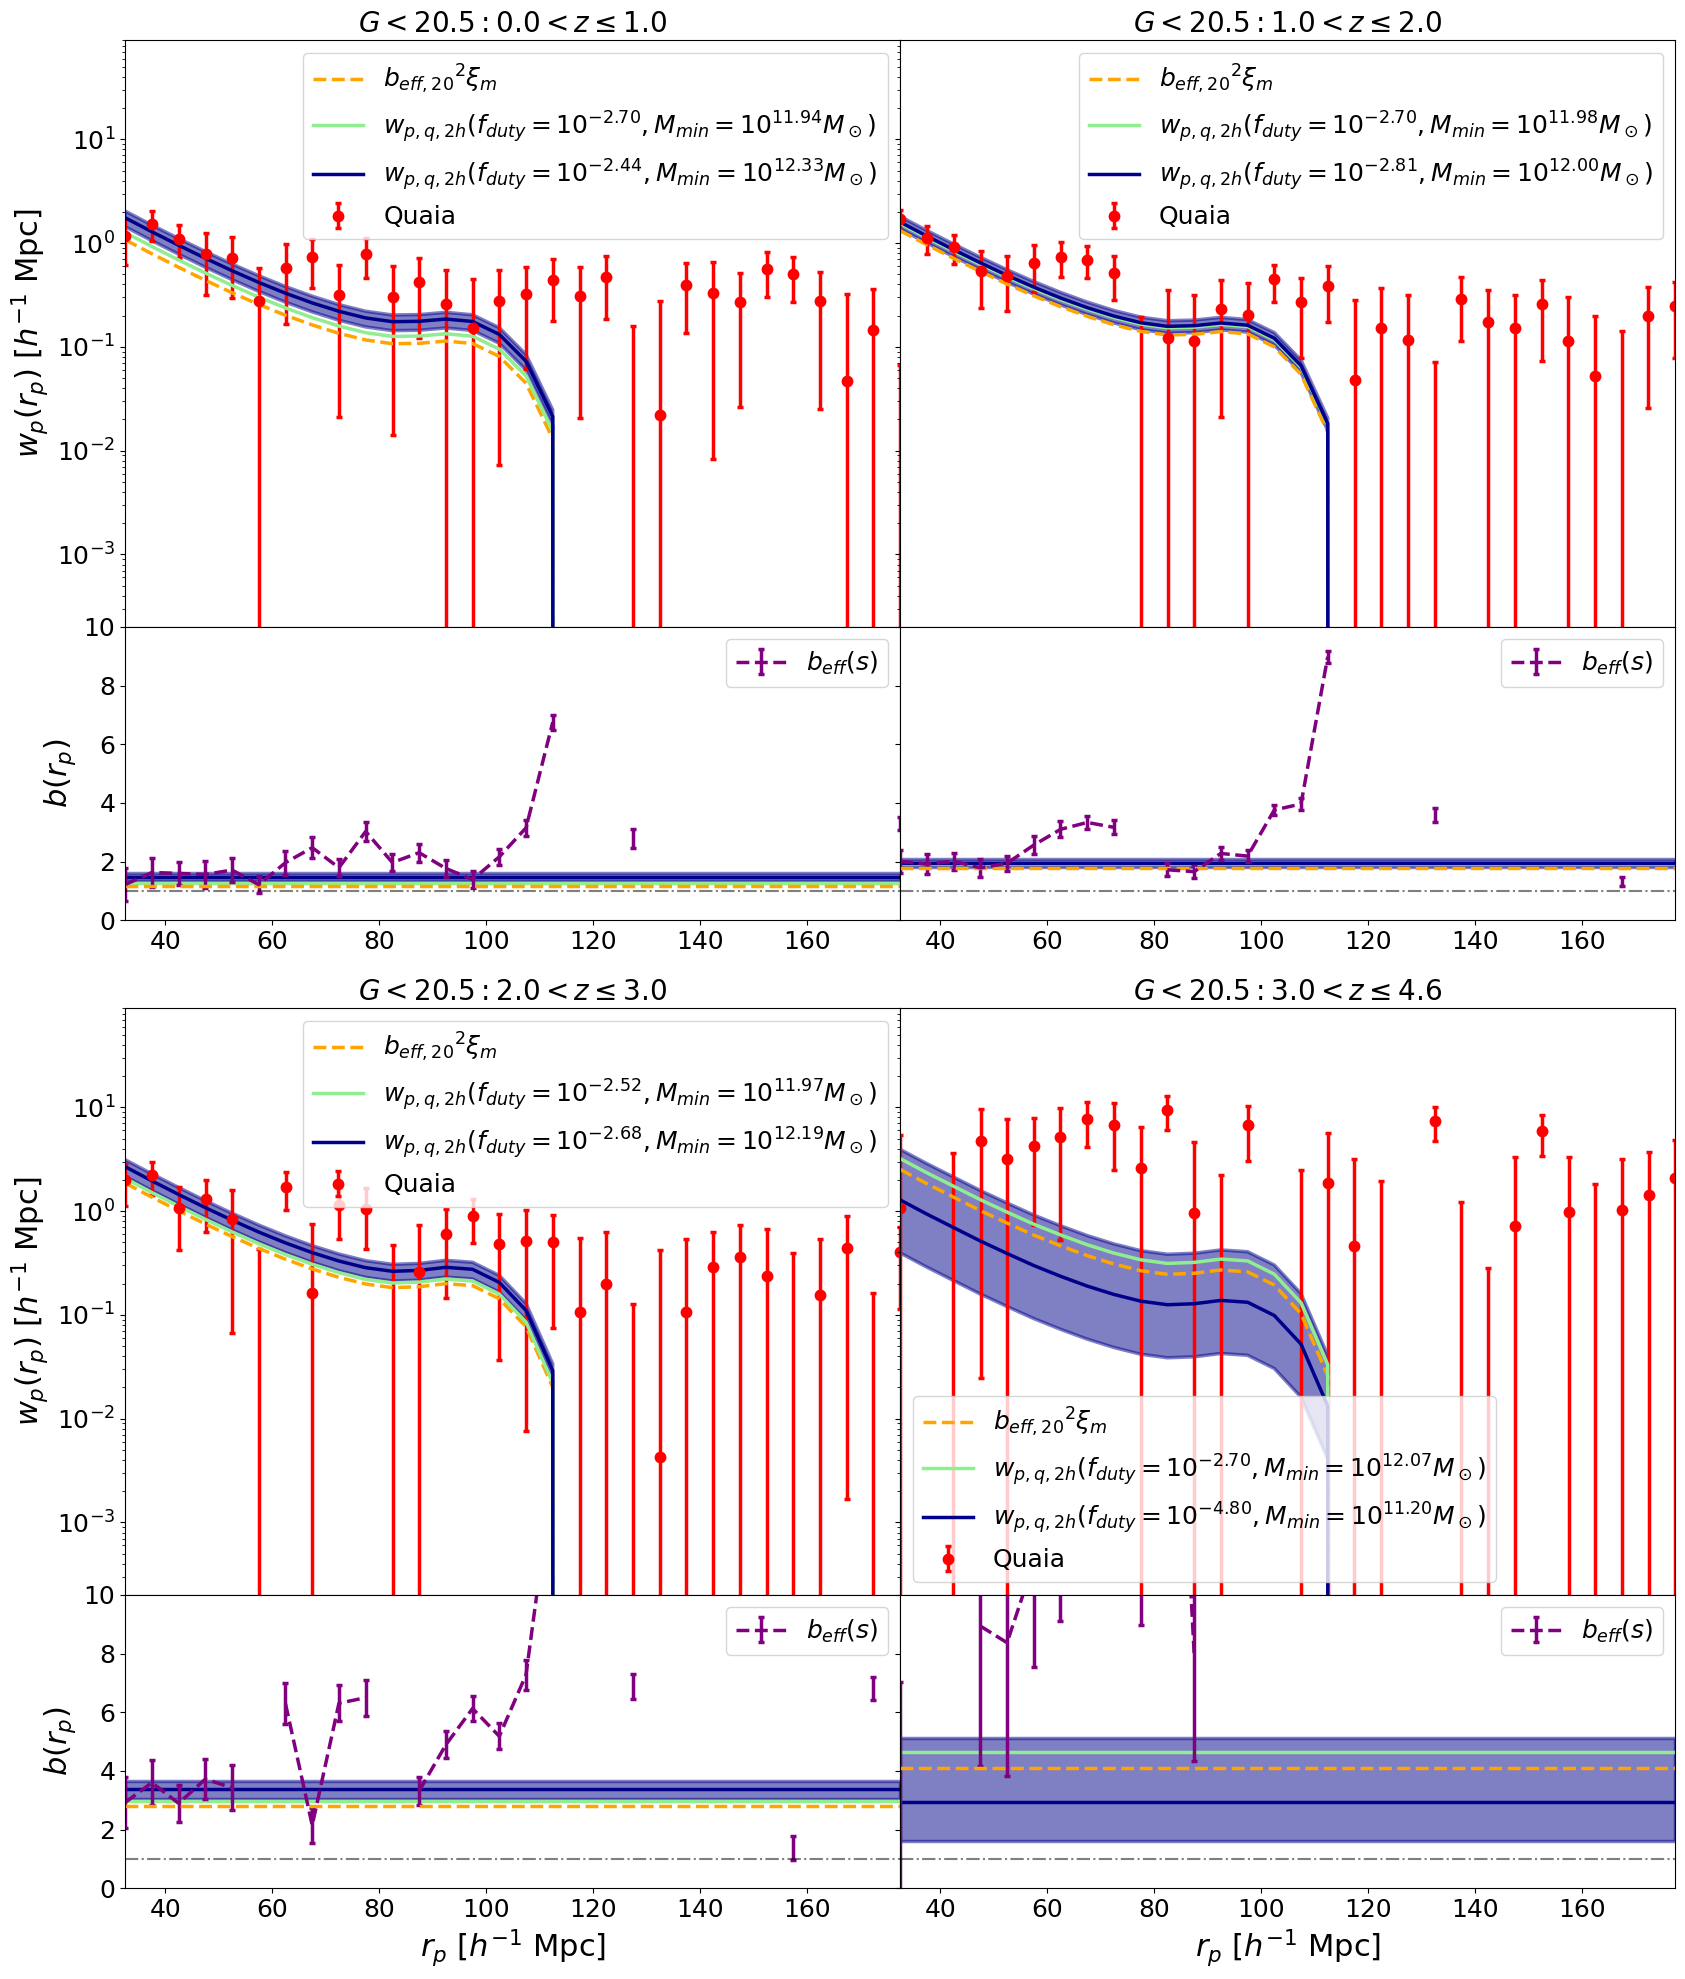

In [151]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)
ylim = 2e-4, 9e1

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])

    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_Planck_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, mask))
   
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins), b_eff_wp20[j]**2*wp_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    if quaia.recenter(rbins)[0] < 30:
        ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                          alpha = 0.5)

    # old fit
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)
    ax1.plot(quaia.recenter(rbins), wp_2h_zbin, linewidth = 2.5, 
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')
    
    wp_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        wp_2h_sample, b_q_sample = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
        b_q_samples.append(b_q_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.plot(quaia.recenter(rbins), wp_2h_50, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q_50, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins), b_wp_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    if quaia.recenter(rbins)[0] < 30:
        ax2.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax2.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                          alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.1f}<z \leq{:.1f}$'.format(G_hi, z_bins[j], z_bins[j+1]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

In [152]:
cmap_rocket = sns.color_palette("flare_r", n_colors = len(z_array))
cmap_rocket

[(0.47936222, 0.18006056, 0.43733022),
 (0.66635279, 0.22717328, 0.43008427),
 (0.83765537, 0.30784814, 0.3723105),
 (0.90732341, 0.4939774, 0.38990532)]

<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_23422/15638767.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


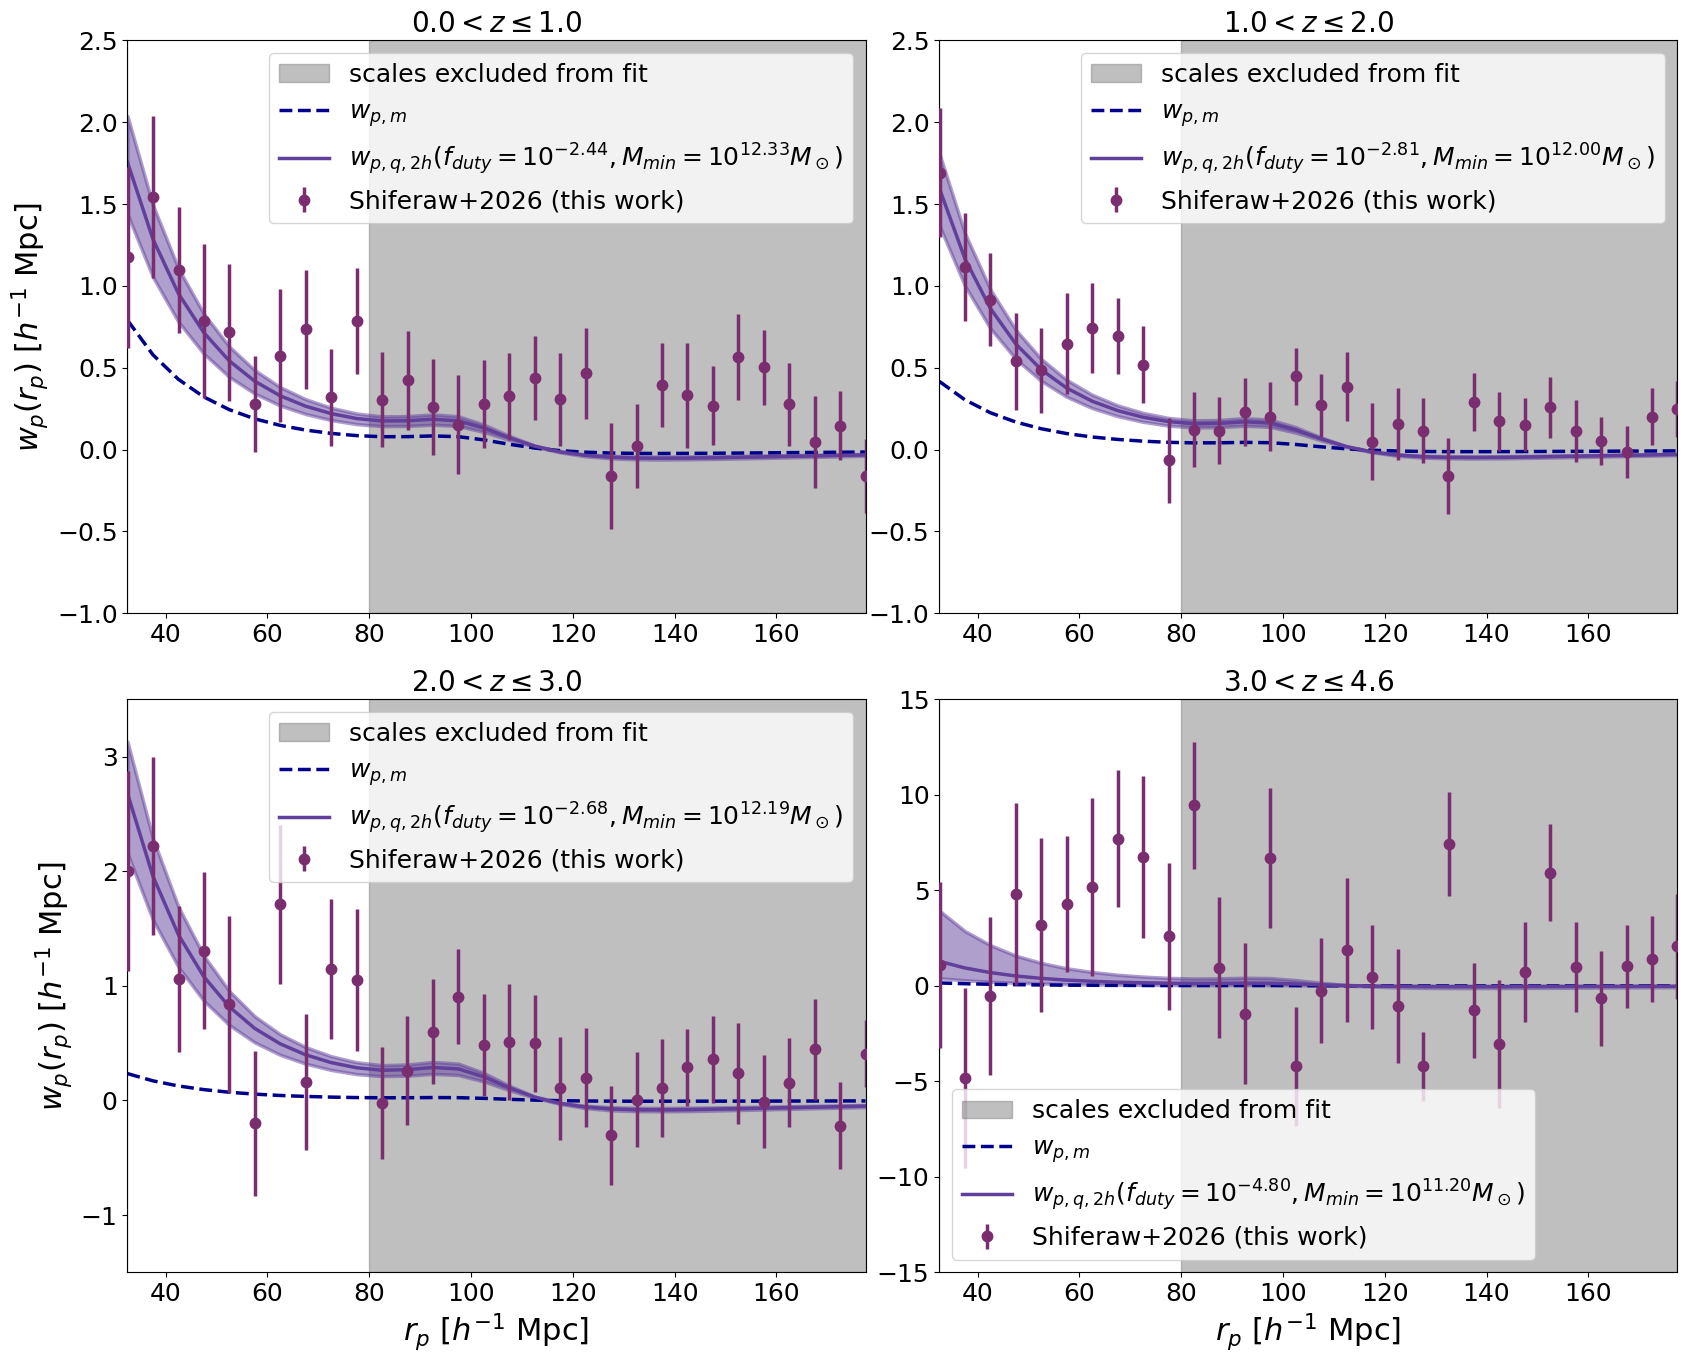

In [153]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0.1)
ylim = [-1,2.5], [-1,2.5], [-1.5, 3.5], [-15,15]

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
    
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_Lmax-20.0_N{}_Planck_MC_mask{}.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N, mask))
           
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', label = r'Shiferaw+2026 (this work)', color = cmap_rocket[0],
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, linestyle = 'none', zorder = 3) #capsize = 2.5
    if quaia.recenter(rbins)[-1] > 80:
        ax1.fill_betweenx(np.linspace(ylim[j][0], ylim[j][1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(ylim[j][0], ylim[j][1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                          alpha = 0.5)
        
    ax1.plot(quaia.recenter(rbins), wp_matter_chi2[j], linewidth = 2.5,
             label = r'$w_{{p,m}}$', linestyle = '--', 
             color = 'darkblue')

    wp_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        wp_2h_sample, _ = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    ax1.plot(quaia.recenter(rbins), wp_2h_50, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = cmap_purple[-1])
    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = cmap_purple[-1])    

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(ylim[j])
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

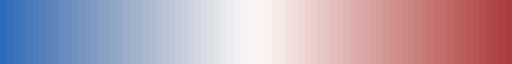

In [154]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_23422/3292803941.py:35: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
/tmp/ipykernel_23422/3292803941.py:52: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


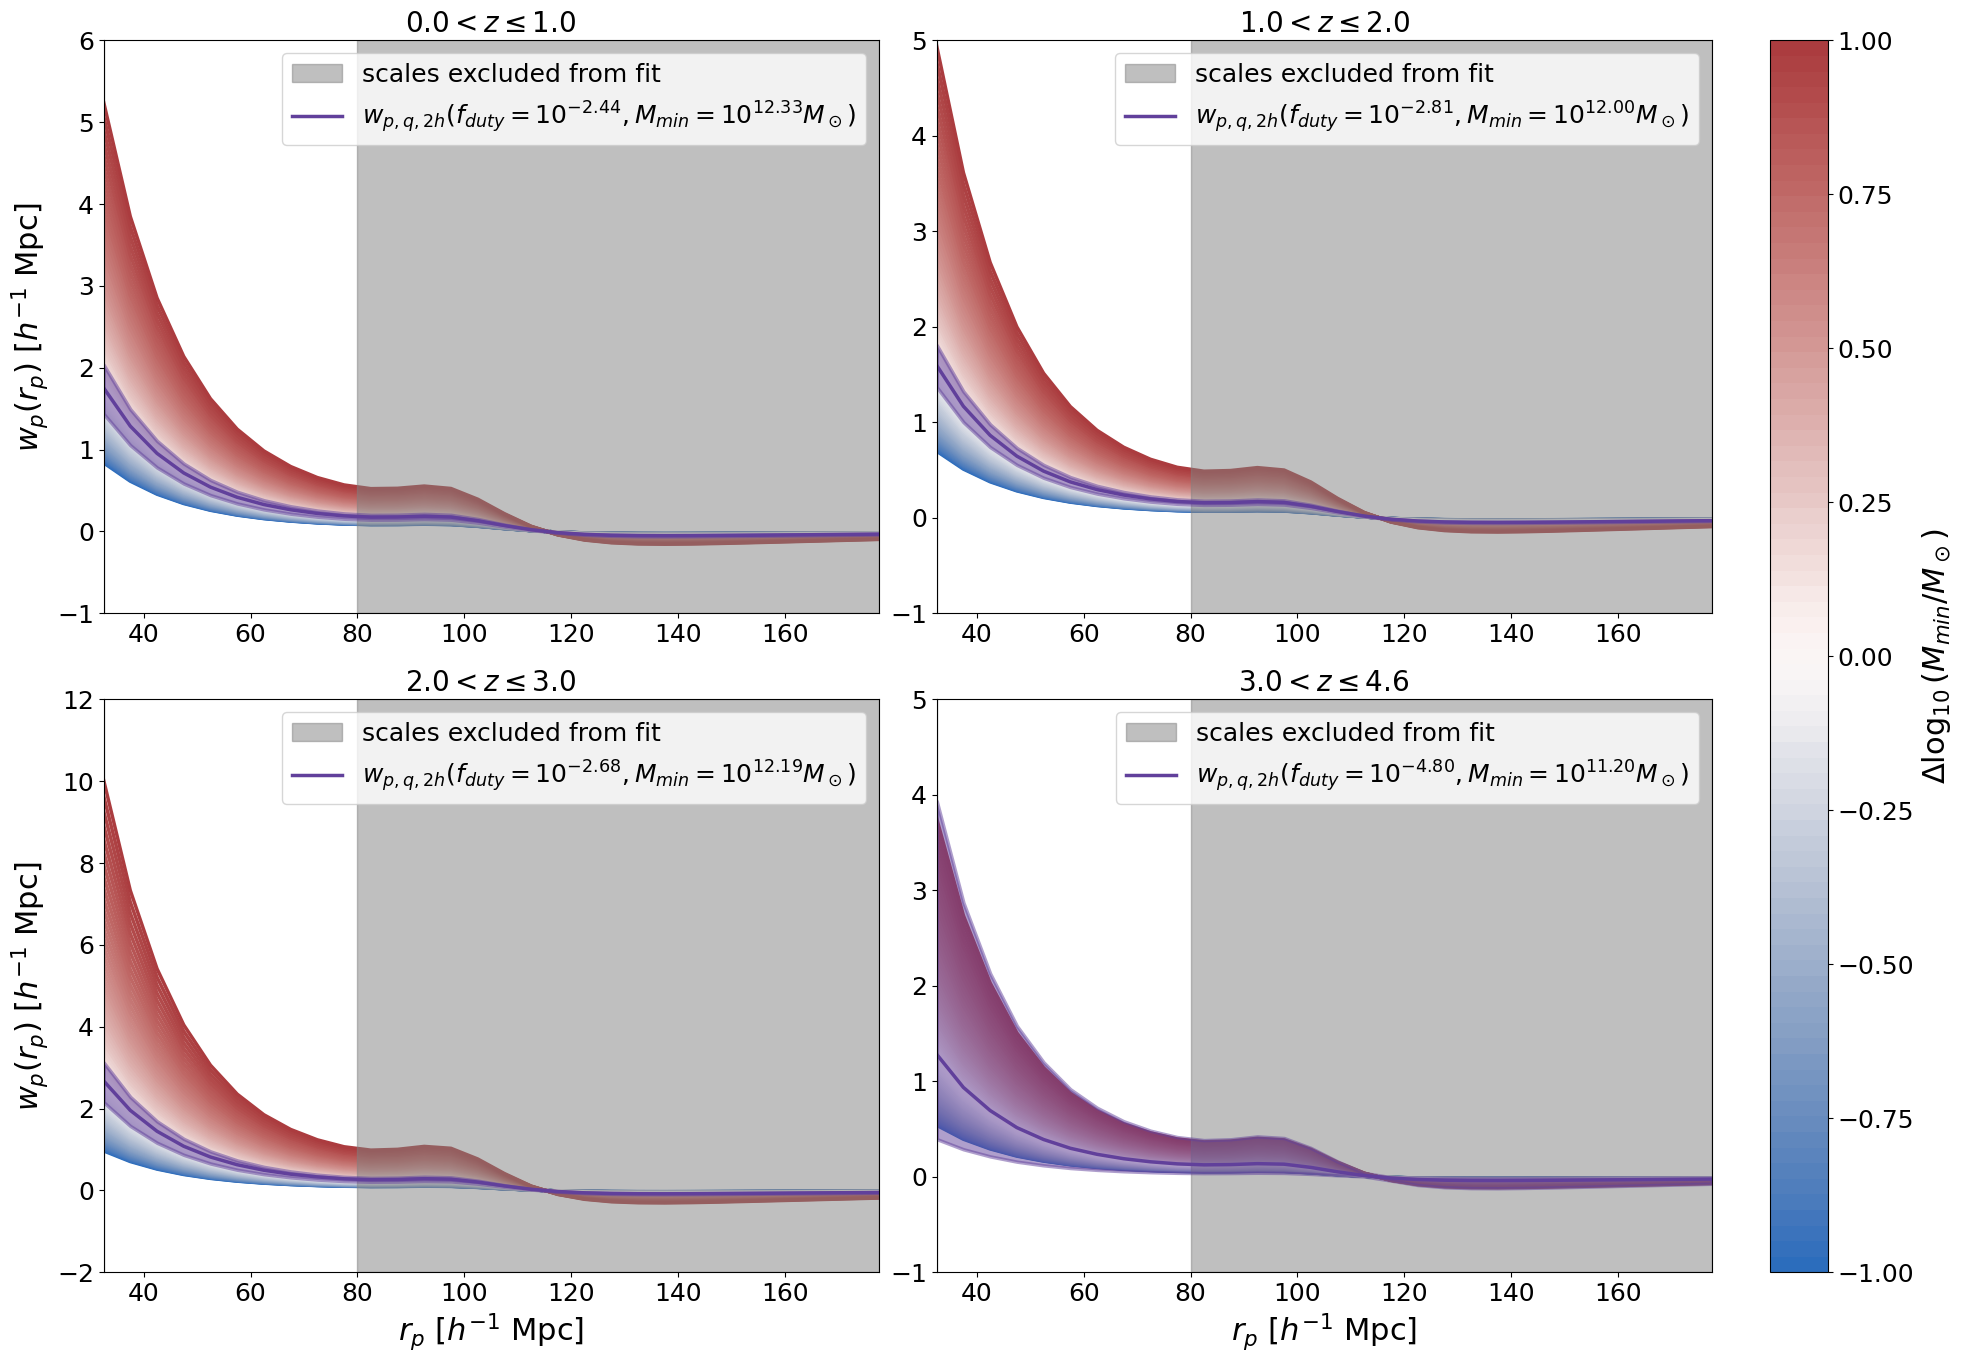

In [155]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (22.25, 16))#20
gs = gridspec.GridSpec(2, 5, hspace = 0.15, wspace = 0, width_ratios = [1,0.075,1,0.075,0.075])
ylim = [-1,6], [-1, 5], [-2, 12], [-1,5]

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    if quaia.recenter(rbins)[-1] > 80:
        ax1.fill_betweenx(np.linspace(ylim[j][0], ylim[j][1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                          alpha = 0.5, label = 'scales excluded from fit')
        ax1.fill_betweenx(np.linspace(ylim[j][0], ylim[j][1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                          alpha = 0.5)

    for k in range(len(bins)):
        wp_2h_sample, _ = wp_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)
        ax1.plot(quaia.recenter(rbins), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    wp_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        wp_2h_sample, _ = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    ax1.plot(quaia.recenter(rbins), wp_2h_50, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = cmap_purple[-1])
    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = cmap_purple[-1])    #darkblue

    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(ylim[j])
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 

    if j == 0 or j == 2:#1
        l+=1 #2
    elif j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [156]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 50, 84]))
b_q_lo, b_q_mid, b_q_hi = np.array(b_q_percentile).T

<>:49: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_23422/3930186336.py:49: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


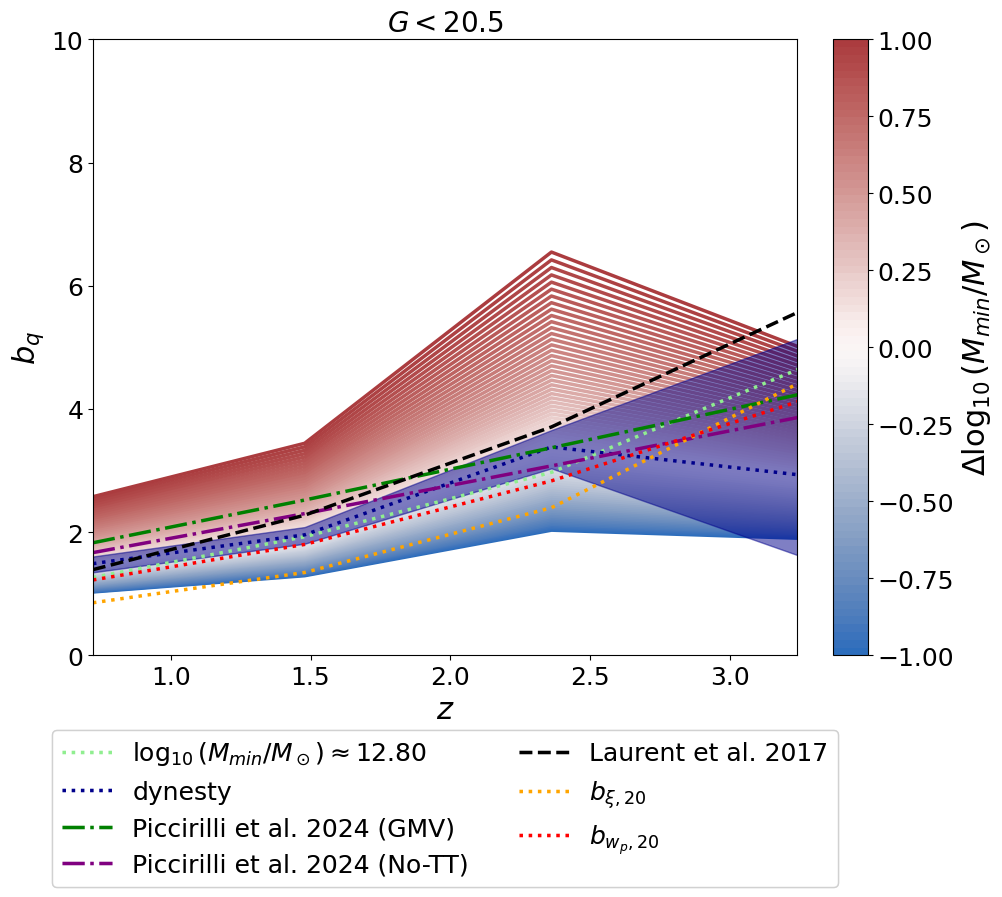

In [157]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_q_mid, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [wp_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [158]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 50, 84]))
M_h_lo, M_h_mid, M_h_hi = np.array(M_h_percentile).T

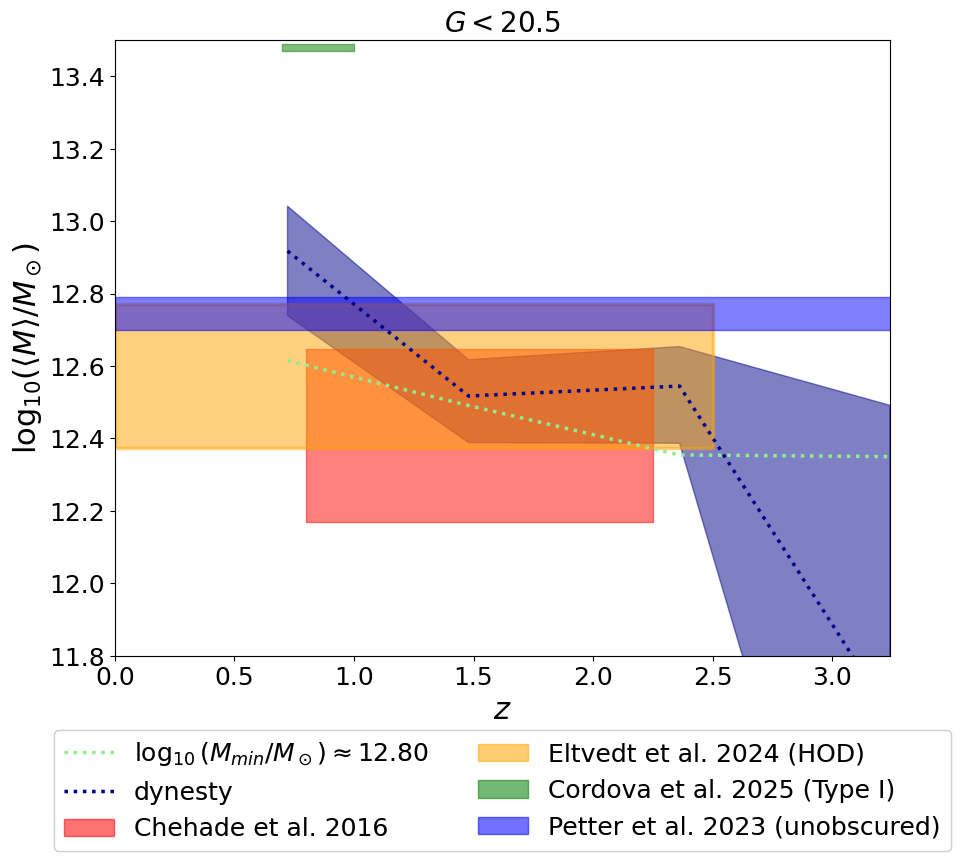

In [159]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                # mpatches.Patch(color='lightgreen', alpha = 0.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [#'Giner Mascarell et al. 2025', 
                                          r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_23422/2304443408.py:44: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


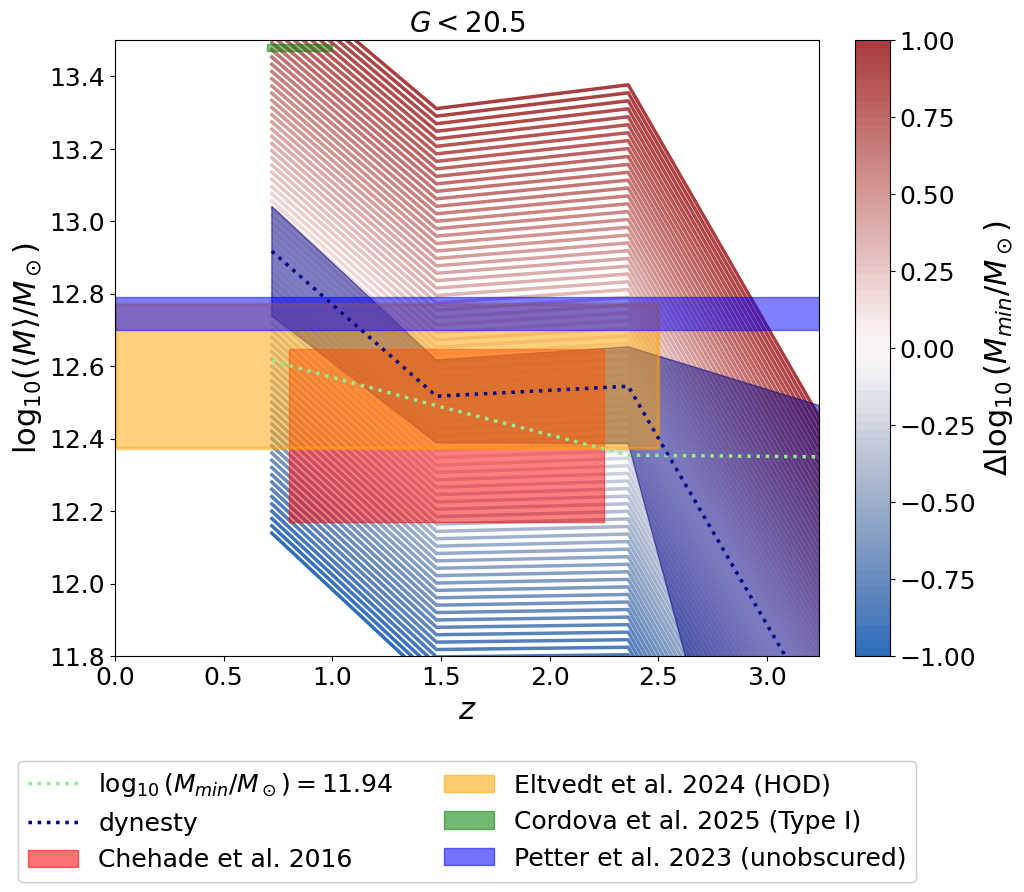

In [160]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, np.log10(M_h_mid), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [161]:
fduty_array = np.logspace(-5,0, 51) #-4

In [162]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [163]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 50, 84]))
n_q_theory_fit_lo, n_q_theory_fit_mid, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_23422/1291564972.py:32: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_23422/1291564972.py:61: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


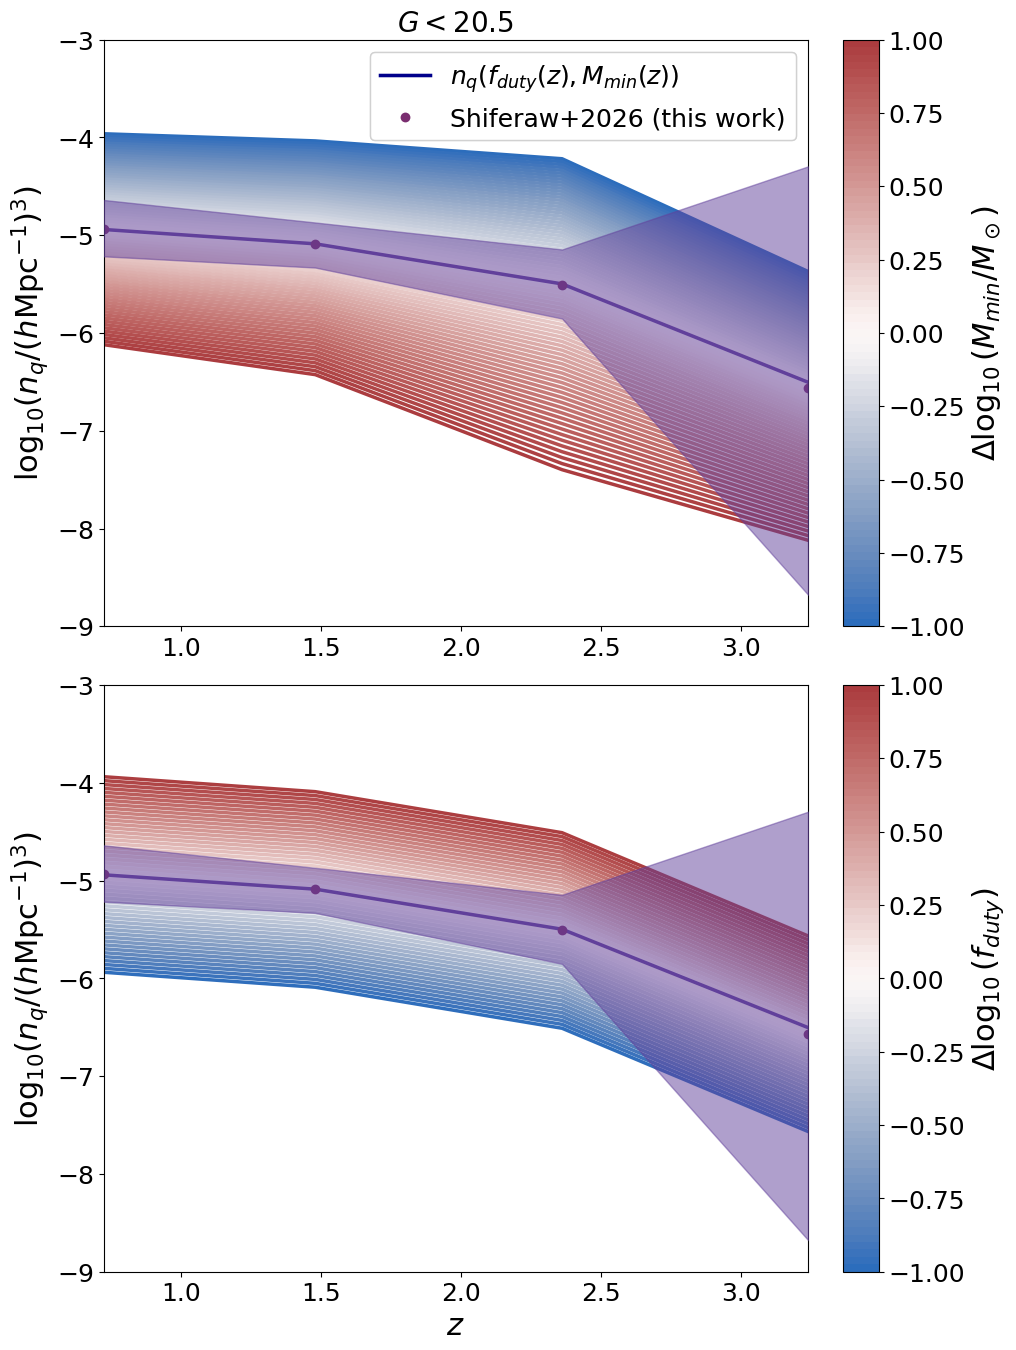

In [164]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -9,-3#-6.75, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])

ax1.plot(zbin, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[-1], linestyle = '-', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[-1], alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[0],
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'darkblue', linestyle = '-', linewidth = 2.5, 
                       label = r'$n_q(f_{{duty}}(z), M_{{min}}(z))$'.format(f_duty[j], M_min[j]),), 
                Line2D([0], [0], color = cmap_rocket[0], marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Shiferaw+2026 (this work)')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_ylabel(r'log$_{10}(n_q/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')

ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])

ax1.plot(zbin, np.log10(n_q_theory_fit_mid), linewidth = 2.5, color = cmap_purple[-1], linestyle = '-', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = cmap_purple[-1], alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = cmap_rocket[0],
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n_q/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()